# MNIST CAPTCHA

Αυτό το starter notebook εστιάζει στην επίλυση του προβλήματος MNIST CAPTCHA. Στόχος είναι να σχεδιάσουμε ένα σύστημα που αναγνωρίζει τα ψηφία και τον τελεστή από μία εικόνα τύπου "AB ± CD", ώστε να υπολογίζει το τελικό αποτέλεσμα. Το notebook παρέχει τα ελάχιστα βήματα: εισαγωγές βιβλιοθηκών, λήψη του MNIST dataset και έναν απλό ταξινομητή, ώστε να συνεχίσετε με δικές σας υλοποιήσεις.

**Αυτό το Notebook είναι Read-Only** - οπότε πρέπει να αποθηκεύσετε ένα αντίγραφο στο δικό σας Google Drive.


In [1]:
# import io
# import nbformat
# from nbconvert import PythonExporter
# from google.colab import files

# # --- FIX REQUIRED: Please update 'YOUR_NOTEBOOK_PATH.ipynb' with the actual path to your notebook file. ---
# # Example: If your notebook is named 'MyProject.ipynb' in 'Colab Notebooks' folder on Drive,
# # the path would be '/content/drive/MyDrive/Colab Notebooks/MyProject.ipynb'

# # Get the current notebook in JSON format
# # NOTE: This line requires you to manually specify the path to your notebook.
# # If your notebook is saved in Google Drive, ensure Google Drive is mounted
# # and replace 'YOUR_NOTEBOOK_PATH.ipynb' with the correct path.
# ?
# # Mount Google drive
# from google.colab import drive
# drive.mount('/content/drive')
# notebook_path = '/content/drive/MyDrive/Colab Notebooks/captcha.ipynb' # <--- UPDATE THIS PATH
# notebook_json = nbformat.reads(open(notebook_path).read(), as_version=4)

# # Convert to Python script
# exporter = PythonExporter()
# python_script, _ = exporter.from_notebook_node(notebook_json)

# # Save to a .py file
# output_filename = 'notebook.py'
# with open(output_filename, 'w') as f:
#     f.write(python_script)

# print(f'Notebook successfully converted to {output_filename}')

# # Download the .py file
# files.download(output_filename)

## Εισαγωγές βιβλιοθηκών

Χρειαζόμαστε την NumPy για διαχείριση πινάκων και την PyTorch για τη δημιουργία και εκπαίδευση νευρωνικών δικτύων. Θα χρησιμοποιήσουμε επίσης το torchvision για να κατεβάσουμε το MNIST dataset μαζί με βασικούς μετασχηματισμούς.


In [2]:
import numpy as np
import torch
from torch import nn
from torchvision import datasets, transforms
from gdown import download
from PIL import Image

In [3]:
import os

# Create the .cache/gdown directory if it doesn't exist
cookies_dir = os.path.expanduser('~/.cache/gdown')
os.makedirs(cookies_dir, exist_ok=True)

# Move the uploaded cookies.txt to the gdown cache directory
# Assuming you uploaded cookies.txt to the root of the Colab session storage
!mv /content/cookies.txt ~/.cache/gdown/cookies.txt

print(f"cookies.txt moved to {os.path.join(cookies_dir, 'cookies.txt')}")

mv: cannot stat '/content/cookies.txt': No such file or directory
cookies.txt moved to /root/.cache/gdown/cookies.txt


## Λήψη των αρχείων

In [4]:
download(id='18IZn5DroVvTkGJEKn5w15RuT61ET9HP0', output='public-clean.png', quiet=False)
download(id='1y3xX9VrM7EtYf1W-3vr-PETE19FnTKHR', output='public-clean.txt', quiet=False)

download(id='1cvDlXQrkLvR_tQBydyms-dt-VSjB7RlG', output='public-noisy.png', quiet=False)
download(id='1V-e76Q8Op3FWFEqb42bvJKllM5LfCdVS', output='public-noisy.txt', quiet=False)

download(id='1JfbYOpBHNrlz-fqgOtLZ8QDidxznug7U', output='private-clean.png', quiet=False)
download(id='1WtozDPV0FjmPthKBBiqBPfd-lhCMxfzk', output='private-noisy.png', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=18IZn5DroVvTkGJEKn5w15RuT61ET9HP0
To: /content/public-clean.png
100%|██████████| 1.92M/1.92M [00:00<00:00, 45.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1y3xX9VrM7EtYf1W-3vr-PETE19FnTKHR
To: /content/public-clean.txt
100%|██████████| 8.47k/8.47k [00:00<00:00, 25.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1cvDlXQrkLvR_tQBydyms-dt-VSjB7RlG
To: /content/public-noisy.png
100%|██████████| 2.89M/2.89M [00:00<00:00, 83.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1V-e76Q8Op3FWFEqb42bvJKllM5LfCdVS
To: /content/public-noisy.txt
100%|██████████| 8.49k/8.49k [00:00<00:00, 24.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JfbYOpBHNrlz-fqgOtLZ8QDidxznug7U
To: /content/private-clean.png
100%|██████████| 1.92M/1.92M [00:00<00:00, 87.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1WtozDPV0FjmPthKBBiqBPfd-lhCMxfzk
To: /content/private-noisy.png
100%|██████████| 2.89M/2.89M [00:00<0

'private-noisy.png'

In [5]:
import random
import numpy as np
import torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Global random seed set to {seed} for reproducibility.")

Global random seed set to 42 for reproducibility.


In [6]:
import cv2
import numpy as np
import torch

def find_largest_connected_component(image_tensor):
    """
    Applies a median filter for salt-and-pepper noise removal, then extracts
    the largest connected component to remove isolated noise while preserving
    grayscale values of the main digit.
    """
    # Convert PyTorch tensor to NumPy array if necessary
    is_torch_tensor = False
    if isinstance(image_tensor, torch.Tensor):
        is_torch_tensor = True
        # Detach from GPU and convert to CPU numpy array
        image_np = image_tensor.detach().cpu().numpy()
    else:
        image_np = image_tensor

    # Ensure image_np is a 2D array (H, W)
    if image_np.ndim == 4 and image_np.shape[0] == 1 and image_np.shape[1] == 1:
        image_np = image_np[0, 0, :, :] # Take the single image from (1, 1, H, W)
    elif image_np.ndim == 3 and image_np.shape[0] == 1:
        image_np = image_np[0, :, :] # Take the single image from (1, H, W)
    elif image_np.ndim == 3 and image_np.shape[-1] == 1:
        image_np = image_np[:, :, 0] # Take the single image from (H, W, 1)
    elif image_np.ndim == 2:
        pass # Already (H, W)
    else:
        raise ValueError(f"find_largest_connected_component: Unexpected input shape for image_np: {image_np.shape}")

    # Now image_np is guaranteed to be 2D (H, W).
    # Step 1: Apply Median Filter to remove salt-and-pepper noise while preserving grayscale.
    # Convert to uint8 for OpenCV operations (medianBlur expects uint8).
    # Scale from [0,1] float to [0,255] uint8.
    image_uint8 = (image_np * 255).astype(np.uint8)
    median_filtered_uint8 = cv2.medianBlur(image_uint8, 3)

    # Step 2: Extract the largest connected component from the median-filtered image.
    # Binarize the median-filtered image for connected component analysis.
    # Otsu's method will find an optimal threshold.
    _, binary_for_cc = cv2.threshold(median_filtered_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Find all connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_for_cc, 8, cv2.CV_32S)

    # The first component (label 0) is typically the background, so we skip it.
    # Find the largest component (excluding the background)
    largest_component_area = 0
    largest_component_label = 0
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > largest_component_area:
            largest_component_area = stats[i, cv2.CC_STAT_AREA]
            largest_component_label = i

    # Create a mask for the largest component (1 for foreground, 0 for background)
    largest_component_mask = np.zeros(labels.shape, dtype=np.uint8)
    largest_component_mask[labels == largest_component_label] = 1 # Use 1 for multiplication

    # Apply this mask to the original median-filtered grayscale image.
    # This preserves grayscale values only within the largest component, removing isolated noise.
    final_cleaned_np = (median_filtered_uint8 / 255.0) * largest_component_mask

    # Convert back to PyTorch tensor if the input was a tensor
    if is_torch_tensor:
        # Add channel dimension back (1, H, W) for compatibility with T.Compose
        output_image_tensor = torch.from_numpy(final_cleaned_np).float().unsqueeze(0)
        return output_image_tensor
    else:
        return final_cleaned_np # Return normalized numpy array if input was numpy

In [7]:
import torchvision.transforms as T

class AddSaltPepperNoise(object):
    def __init__(self, amount=0.05, salt_vs_pepper=0.5):
        self.amount = amount
        self.salt_vs_pepper = salt_vs_pepper

    def __call__(self, tensor):
        # tensor is (C, H, W)
        C, H, W = tensor.shape

        # We assume grayscale images (C=1) for MNIST.
        # Create a mask for pixels with exactly '0.0' value as requested by the user.
        digit_mask = (tensor[0, :, :] == 0.0)

        # Get the coordinates (row, col) of these eligible pixels
        coords_h, coords_w = digit_mask.nonzero(as_tuple=True)

        num_eligible_pixels = coords_h.numel()
        if num_eligible_pixels == 0:
            return tensor # No '0' pixels to add noise to, return original tensor

        num_salt_pepper = int(self.amount * num_eligible_pixels)
        if num_salt_pepper == 0:
            return tensor # No noise to add based on amount

        # Randomly select a subset of these eligible coordinates
        # Ensure num_salt_pepper does not exceed available eligible pixels
        num_salt_pepper = min(num_salt_pepper, num_eligible_pixels)
        perm = torch.randperm(num_eligible_pixels)[:num_salt_pepper]

        selected_h = coords_h[perm]
        selected_w = coords_w[perm]

        # Create a mask for salt (value 1) and pepper (value 0) for the selected pixels
        salt_noise_mask = torch.rand(num_salt_pepper) < self.salt_vs_pepper

        # Apply salt noise (set to 1.0 - white) on the selected digit pixels
        tensor[0, selected_h[salt_noise_mask], selected_w[salt_noise_mask]] = 1.0
        # Apply pepper noise (set to 0.0 - black) on the selected digit pixels
        tensor[0, selected_h[~salt_noise_mask], selected_w[~salt_noise_mask]] = 0.0

        return tensor

augment = T.Compose([
    T.RandomRotation(15),
    T.ToTensor(),
    # Apply salt-and-pepper noise to strict 0.0 values (background)
    AddSaltPepperNoise(amount=0.1), # Increased noise amount 0.85
    # Removed: T.Lambda(lambda x: x + 0.01 * torch.randn_like(x)),  # Gaussian noise
    T.Lambda(lambda x: torch.clamp(x, 0., 1.)),
    # Removed T.Normalize to address the user's request for 'non floating point noise'
    # The values will now remain in the 0.0-1.0 range after noise application.
    # T.Normalize((0.1307,), (0.3081,))
])

In [8]:
from torch._prims_common import Tensor
import os
def showImage(tensor):
    transform = transforms.ToPILImage()
    return transform(1-tensor)
def readExamples(file_name):
    transform = transforms.ToTensor()
    image = Image.open(file_name + '.png').convert('L')
    tensor = 1-transform(image)
    X = tensor.reshape(-1,1,28,140)
    if os.path.exists(file_name + '.txt'):
        with open(file_name + '.txt') as f:
            lines = f.readlines()
    else:
        lines = ['']*X.shape[0]
    return X, lines

clean_equations, clean_results = readExamples('public-clean') # or 'public-noisy' or 'private-clean' or 'private-noisy'
noisy_equations, noisy_results = readExamples('public-noisy')

# Extract individual digits from clean_equations
digit1 = clean_equations[:, :, :, 0:28]
digit2 = clean_equations[:, :, :, 28:56]
digit3 = clean_equations[:, :, :, 84:112]
digit4 = clean_equations[:, :, :, 112:140]

# Concatenate along the batch dimension to create a tensor of individual digit images
clean_numbers = torch.cat((digit1, digit2, digit3, digit4), dim=0)

# Extract individual digits from noisy_equations
digit1 = noisy_equations[:, :, :, 0:28]
digit2 = noisy_equations[:, :, :, 28:56]
digit3 = noisy_equations[:, :, :, 84:112]
digit4 = noisy_equations[:, :, :, 112:140]

noisy_numbers = torch.cat((digit1, digit2, digit3, digit4), dim=0)

clean_sign = clean_equations[:, :, :, 56:84]
noisy_sign = noisy_equations[:, :, :, 56:84]
print(clean_numbers.shape)
print(clean_sign.shape)
print(noisy_sign.shape)
print(noisy_results[0])
showImage(clean_equations[0])

torch.Size([10000, 1, 28, 28])
torch.Size([2500, 1, 28, 28])
torch.Size([2500, 1, 28, 28])
-12



In [9]:
from torch.utils.data import DataLoader, ConcatDataset
import torchvision.transforms as T
from torchvision import datasets

transform = T.ToTensor()
clean_train_mnist_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
# Corrected: Create a new MNIST dataset with the 'augment' transform applied on-the-fly.
# The `denoise_equation` function is intended for CAPTCHA equations (28x140), not single MNIST digits (28x28).
# The `augment` transform already applies noise and transformations for single digits efficiently.
noisy_train_mnist_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=augment)
train_mnist_dataset = train_mnist_ds = ConcatDataset([clean_train_mnist_dataset, noisy_train_mnist_dataset])
# train_mnist_dataset = train_mnist_ds=  clean_train_mnist_dataset

test_clean_mnist_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_noisy_mnist_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=augment)
# test_clean_mnist_dataset = ConcatDataset([test_clean_mnist_dataset, test_noisy_mnist_dataset])

print(f"Train samples: {len(train_mnist_dataset)}") # Changed from clean_train_mnist_dataset
print(f"Test samples: {len(test_clean_mnist_dataset)}")
showImage(noisy_train_mnist_dataset[0][0])

Train samples: 120000
Test samples: 10000


Testing find_largest_connected_component function...


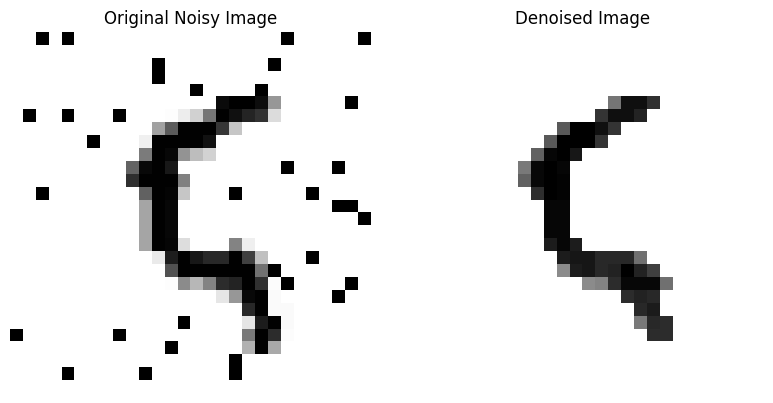

Test complete.


In [10]:
import matplotlib.pyplot as plt
print("Testing find_largest_connected_component function...")

# Get a sample noisy image from the dataset
# Ensure noisy_train_mnist_dataset has been loaded (e.g., by running cell 5gxXGhz8WWfr)
noisy_image_sample, _ = noisy_train_mnist_dataset[100] # Get 10th image for example

# Apply the denoising function
# The function expects a tensor (C, H, W) or (B, C, H, W)
# noisy_image_sample is (1, 28, 28)
denoised_image_sample = find_largest_connected_component(noisy_image_sample)

# Display original and denoised images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(showImage(noisy_image_sample), cmap='gray')
axes[0].set_title('Original Noisy Image')
axes[0].axis('off')

# Squeeze the denoised image to (H, W) for showImage if it's (1, 1, H, W)
axes[1].imshow(showImage(denoised_image_sample.squeeze()), cmap='gray')
axes[1].set_title('Denoised Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Test complete.")

In [11]:
import os
from PIL import Image
import torch
from torchvision import transforms
import cv2
import numpy as np


def denoise_equation(x):
   if x.dim() == 3:
      x = x.unsqueeze(0) # Ensure x is (1, 1, 28, 140)

   # Extract all five segments (digits and operator)
   # Apply find_largest_connected_component to each segment
   digit1_img = find_largest_connected_component(x[:, :, :, 0:28])
   digit2_img = find_largest_connected_component(x[:, :, :, 28:56])
   operator_img = find_largest_connected_component(x[:, :, :, 56:84])
   digit3_img = find_largest_connected_component(x[:, :, :, 84:112])
   digit4_img = find_largest_connected_component(x[:, :, :, 112:140])

   # Apply smoothing to each component
   kernel_size = (3, 3) # Define a kernel size for Gaussian blur
   sigma_x = 0 # Standard deviation in X direction. 0 means calculated from kernel size

   # Convert to numpy, apply blur, then convert back to tensor
   # Ensure tensor is on CPU before converting to numpy
  #  digit1_img = torch.from_numpy(cv2.GaussianBlur(digit1_img.squeeze().cpu().numpy(), kernel_size, sigma_x)).float().unsqueeze(0).unsqueeze(0)
  #  digit2_img = torch.from_numpy(cv2.GaussianBlur(digit2_img.squeeze().cpu().numpy(), kernel_size, sigma_x)).float().unsqueeze(0).unsqueeze(0)
  #  operator_img = torch.from_numpy(cv2.GaussianBlur(operator_img.squeeze().cpu().numpy(), kernel_size, sigma_x)).float().unsqueeze(0).unsqueeze(0)
  #  digit3_img = torch.from_numpy(cv2.GaussianBlur(digit3_img.squeeze().cpu().numpy(), kernel_size, sigma_x)).float().unsqueeze(0).unsqueeze(0)
  #  digit4_img = torch.from_numpy(cv2.GaussianBlur(digit4_img.squeeze().cpu().numpy(), kernel_size, sigma_x)).float().unsqueeze(0).unsqueeze(0)

   # Concatenate along the width dimension (dim=2) to reconstruct the full equation
   return torch.cat((digit1_img, digit2_img, operator_img, digit3_img, digit4_img), dim=2)

## Λήψη του MNIST dataset

Θα κατεβάσουμε το κλασικό MNIST dataset μέσω του torchvision και θα το μετατρέψουμε σε tensors ώστε να χρησιμοποιηθεί αργότερα στην εκπαίδευση.


In [12]:
import torch
import torchvision.transforms as T




# Apply this new transform to the MNIST datasets
# clean_train_mnist_dataset.transform = augment
# test_mnist_dataset.transform = augment

showImage(clean_train_mnist_dataset.data[2])

In [13]:
from sklearn.model_selection import train_test_split


clean_x_train, sign_x_test, sign_y_train, sign_y_test = train_test_split(clean_equations, clean_results, test_size=.6, shuffle=True, random_state=175)
showImage(clean_x_train[0])
print(sign_y_train)

['15\n', '112\n', '-43\n', '-5\n', '115\n', '49\n', '-17\n', '143\n', '2\n', '95\n', '-26\n', '68\n', '75\n', '71\n', '73\n', '-47\n', '34\n', '40\n', '21\n', '47\n', '65\n', '91\n', '26\n', '149\n', '-79\n', '186\n', '43\n', '141\n', '-50\n', '82\n', '97\n', '-5\n', '27\n', '-48\n', '24\n', '2\n', '5\n', '85\n', '62\n', '-38\n', '92\n', '4\n', '-18\n', '90\n', '177\n', '-20\n', '53\n', '45\n', '-22\n', '123\n', '28\n', '-64\n', '76\n', '62\n', '161\n', '-55\n', '-33\n', '120\n', '105\n', '31\n', '51\n', '103\n', '-56\n', '20\n', '66\n', '120\n', '68\n', '36\n', '-5\n', '64\n', '81\n', '31\n', '113\n', '-12\n', '168\n', '-82\n', '74\n', '53\n', '19\n', '96\n', '74\n', '-20\n', '111\n', '126\n', '35\n', '67\n', '51\n', '-18\n', '-63\n', '117\n', '85\n', '-33\n', '120\n', '1\n', '25\n', '102\n', '11\n', '42\n', '32\n', '61\n', '128\n', '-11\n', '32\n', '39\n', '101\n', '1\n', '-29\n', '-5\n', '145\n', '-27\n', '52\n', '100\n', '-7\n', '120\n', '22\n', '-31\n', '100\n', '-55\n', '127\n', 

In [14]:
image, label = clean_train_mnist_dataset[0]
print(label)
showImage(image)

5


In [15]:
# Transformations applied on each image
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensors
    # Removed Normalize for consistency with augment transform, addressing user feedback.
    # transforms.Normalize((0.1307,), (0.3081,))
])

# clean_train_mnist_dataset.transform = transform
# test_mnist_dataset.transform = transform
# sign_x_test.transform = transform
# clean_x_train.transform = transform

# Η Βασική Ιδέα

Για να αυτοματοποιήσουμε την επίλυση των MNIST-CAPTCHA, πρέπει να εκπαιδεύσουμε ένα νευρωνικό που θα μπορεί να αποκωδικοποιήσει το μαθηματικό πρόβλημα από τα ψηφία του MNIST.

Το πρώτο βήμα είναι να εκπαιδεύσουμε ένα νευρωνικό δίκτυο που μπορεί να αναγνωρίσει να ψηφία ένα ένα.

Το επόμενο βήμα είναι να ξεχωρίσουμε τα ψηφία από το Captcha πρόβλημα, να χρησιμοποιήσουμε το εκπαιδευμένο νευρωνικό μας δίκτυο, και μετά να υπολογίσουμε την απάντηση, έχοντας βρεί τους σωστούς αριθμούς.

## Απλό νευρωνικό δίκτυο

Ως ελάχιστη εκκίνηση, ορίζουμε ένα μοντέλο με ένα μόνο γραμμικό επίπεδο (layer) `nn.Linear(28*28, 10)` το οποίο ισοπεδώνει τα pixels και παράγει logits για τις 10 κλάσεις του MNIST.


In [16]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = F.max_pool2d(x, 2)

        x = self.conv2(x)
        x = self.relu(x)
        x = F.max_pool2d(x, 2)

        x = x.view(-1, 320)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [17]:
clean_model = ConvNet()
noisy_model = ConvNet()


In [18]:
def calc_sign(img_tensor):
    # img_tensor is expected to be a 1x1x28x28 tensor representing the operator image
    # Squeeze to get a 28x28 image for easier slicing
    img = img_tensor.squeeze(0).squeeze(0)

    # Central horizontal strip: rows 12 to 16 (indices 11 to 16)
    horizontal_strip = img[13:15, 8:20]
    # Central vertical strip: columns 12 to 16 (indices 11 to 16)
    vertical_strip = img[8:20:, 13:15]

    horizontal_pixel_sum = horizontal_strip.sum().item()
    vertical_pixel_sum = vertical_strip.sum().item()

    # Heuristic: A '+' sign will have a significant vertical component,
    # while a '-' sign will have very little vertical pixel activity.
    # The threshold of 50 is chosen empirically, assuming '1' represents a black pixel (foreground).
    if vertical_pixel_sum/len(vertical_strip) > 1:
        return 0  # Represents '+'
    else:
        return 1  # Represents '-'


In [19]:
n = 979
print(calc_sign(clean_sign[n]))
showImage(clean_sign[n])

0


In [20]:
from torch import optim

import torch
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt

def train(model, train_loader, test_loader, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device, non_blocking=True)

    criterion = torch.nn.CrossEntropyLoss() # With this criterion, no softmax needed
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    train_losses = []
    test_losses = []
    test_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()  # Update the learning rate

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_test_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = total_test_loss / len(test_loader)
        epoch_accuracy = correct / total
        test_losses.append(epoch_loss)
        test_accuracies.append(epoch_accuracy)

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Testing Loss: {test_losses[-1]}, Testing Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Testing Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs+1), test_losses, label='Testing Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), test_accuracies, label='Testing Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    return # train_losses, test_losses, test_accuracies, best_accuracy

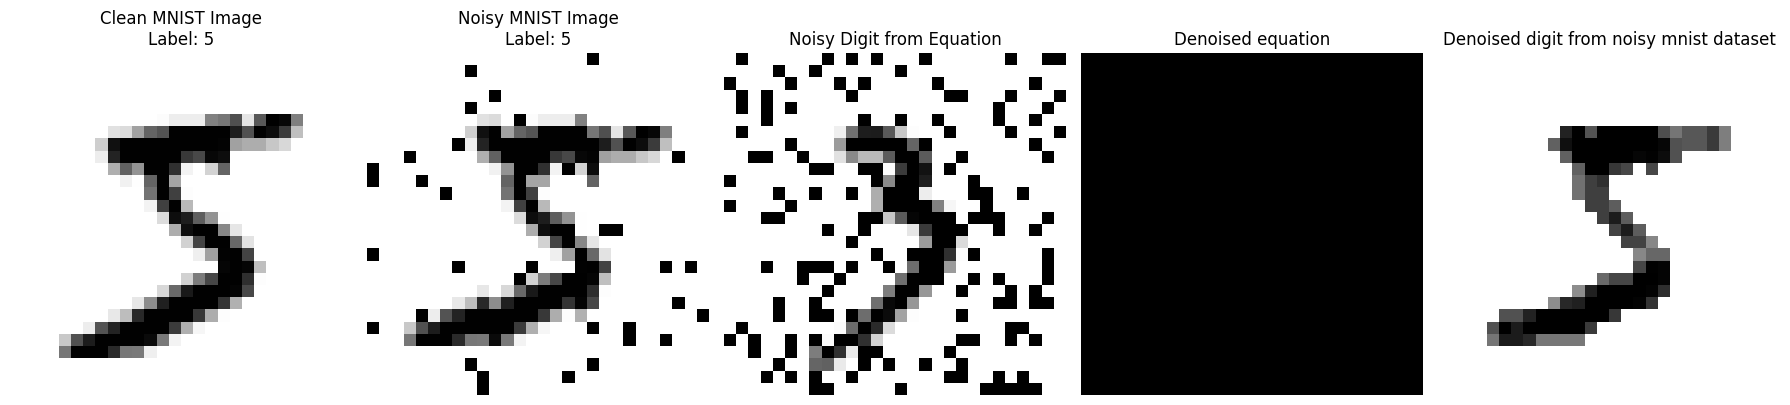

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# Get a clean MNIST image
clean_image, clean_label = clean_train_mnist_dataset[0]
axes[0].imshow(showImage(clean_image), cmap='gray')
axes[0].set_title(f'Clean MNIST Image\nLabel: {clean_label}')
axes[0].axis('off')

# Get a noisy MNIST image
noisy_image, noisy_label = noisy_train_mnist_dataset[0]
axes[1].imshow(showImage(noisy_image), cmap='gray')
axes[1].set_title(f'Noisy MNIST Image\nLabel: {noisy_label}')
axes[1].axis('off')

# Get a noisy digit from an equation
noisy_equation_digit = noisy_numbers[0]
axes[2].imshow(showImage(noisy_equation_digit), cmap='gray')
axes[2].set_title('Noisy Digit from Equation')
axes[2].axis('off')

# Denoised version of the first digit from the first noisy equation
denoised_first_digit = find_largest_connected_component(noisy_equations[0])[:,:,:28].squeeze(0)
axes[3].imshow(showImage(denoised_first_digit), cmap='gray')
axes[3].set_title('Denoised equation')
axes[3].axis('off')

axes[4].imshow(showImage(find_largest_connected_component(noisy_image).squeeze()), cmap='gray') # Added .squeeze() here
axes[4].set_title('Denoised digit from noisy mnist dataset')
axes[4].axis('off')

plt.tight_layout()
plt.show()

# print(clean_image)
# print(noisy_image)

In [22]:
def evaluate(model, data_loader, device):
    model.eval()  # Set model to evaluate mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

In [23]:
# Πόσες παραμέτρους έχει το μοντέλο μας
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Υλοποίηση εκπαίδευσης

Στο επόμενο βήμα θα χρειαστεί να γράψετε τη δική σας συνάρτηση εκπαίδευσης ώστε να προσαρμόσετε το μοντέλο στα δεδομένα και να το επεκτείνετε για τη λύση του MNIST CAPTCHA.


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clean_model.to(device)
clean_equations.to(device)

print(noisy_equations[0])

tensor([[[0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])


In [ ]:
from torch.utils.data import DataLoader

batch_size =128
train_loader = DataLoader(clean_train_mnist_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_clean_mnist_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

optimizer = optim.Adam(clean_model.parameters(), lr=0.004, weight_decay=1e-4)
epochs = 10
train(clean_model, train_loader, test_loader, optimizer, epochs)

Epoch 1/10, Training Loss: 0.215102890947226, Testing Loss: 0.061510251033343843, Testing Accuracy: 0.9816
Epoch 2/10, Training Loss: 0.05998052602637805, Testing Loss: 0.04503297575313268, Testing Accuracy: 0.9851


In [ ]:
from torch.utils.data import DataLoader

batch_size =64
train_loader = DataLoader(noisy_train_mnist_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_noisy_mnist_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

optimizer = optim.Adam(noisy_model.parameters(), lr=0.004, weight_decay=1e-4)
epochs = 10
train(noisy_model, train_loader, test_loader, optimizer, epochs)

In [ ]:
# Με βάση το εκπαιδευμένο μοντέλο υλοποιήστε μια συνάρτηση που υπολογίζει την πράξη στο δοσμένο παράδειγμα
def predict(clean_model, noisy_model, eq, isNoisy):
    # Ensure the model is in evaluation mode
    if isNoisy:
        model = noisy_model
    else:
        model = clean_model
    model.eval()
    device = next(model.parameters()).device # Get the device of the model

    # Move the input equation tensor to the correct device
    eq = eq.to(device)

    processed_eq = eq # Initialize with the original equation (on device)

    with torch.no_grad():
        # processed_eq is now guaranteed to be on the correct device

        # x is currently (channel, height, width) i.e. (1, 28, 140)
        # Unsqueeze to add the batch dimension: (batch, channel, height, width)
        if processed_eq.dim() == 3:
            processed_eq = processed_eq.unsqueeze(0) # Now processed_eq is (1, 1, 28, 140)

        # Extract all five segments (digits and operator)
        # Correctly slice the width dimension to get 28x28 digit images
        digit1_img = processed_eq[:, :, :, 0:28]  # First digit (width 0-28)
        digit2_img = processed_eq[:, :, :, 28:56] # Second digit (width 28-56)
        operator_img_2d = processed_eq[:, :, :, 56:84] # Operator image (width 56-84)
        digit3_img = processed_eq[:, :, :, 84:112] # Third digit (width 84-112)
        digit4_img = processed_eq[:, :, :, 112:140] # Fourth digit (width 112-140)

        # Pass each digit segment through the digit model directly
        output_logits1 = model(digit1_img)
        output_logits2 = model(digit2_img)
        output_logits3 = model(digit3_img)
        output_logits4 = model(digit4_img)

        # Get predicted digits
        predicted_digit1 = torch.argmax(torch.softmax(output_logits1, dim=1), dim=1).item()
        predicted_digit2 = torch.argmax(torch.softmax(output_logits2, dim=1), dim=1).item()
        predicted_digit3 = torch.argmax(torch.softmax(output_logits3, dim=1), dim=1).item()
        predicted_digit4 = torch.argmax(torch.softmax(output_logits4, dim=1), dim=1).item()


        # Use calc_sign to determine the operator
        predicted_operator_as_digit = calc_sign(operator_img_2d) # 0 for '+', 1 for '-'

    num1 = int(str(predicted_digit1) + str(predicted_digit2))
    num2 = int(str(predicted_digit3) + str(predicted_digit4))

    if predicted_operator_as_digit == 0:
        result = num1 + num2
        operator_symbol = "+"
    else:
        result = num1 - num2
        operator_symbol = "-"

    return f"{predicted_digit1}{predicted_digit2}{operator_symbol}{predicted_digit3}{predicted_digit4}={result}"

In [ ]:
n = 9
print(predict(clean_model, noisy_model, clean_equations[n].to(device), True))
print(clean_results[n])
showImage(clean_equations[n])

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display a clean equation
axes[0].imshow(showImage(clean_equations[0]))
axes[0].set_title('Sample from clean_equations')
axes[0].axis('off')

# Display a noisy equation
axes[1].imshow(showImage(noisy_equations[0]))
axes[1].set_title('Sample from noisy_equations')
axes[1].axis('off')

plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Choose a noisy equation
n = 1 # You can change this index to view different examples
noisy_equation_original = noisy_equations[n].to(device)
noisy_equation_cleaned = denoise_equation(noisy_equation_original).to(device) # Move to device after denoising

# Get predictions
prediction_original = predict(clean_model, noisy_model, noisy_equation_original, False) # Original is not denoised before predict
prediction_cleaned = predict(clean_model, noisy_model, noisy_equation_cleaned, True) # Already denoised, so don't denoise again in predict

fig, axes = plt.subplots(1, 4, figsize=(12, 6))

# Display the original noisy equation
axes[0].imshow(showImage(noisy_equation_original.cpu().squeeze(0)), cmap='gray') # Squeeze for display
axes[0].set_title(f'Original Noisy Equation\nPrediction: {prediction_original}')
axes[0].axis('off')

# Display the noisy equation with largest connected component applied
axes[1].imshow(showImage(noisy_equation_cleaned.cpu().squeeze(0)), cmap='gray') # Squeeze for display
axes[1].set_title(f'Noisy Equation with LCC\nPrediction: {prediction_cleaned}')
axes[1].axis('off')

axes[2].imshow(showImage(test_noisy_mnist_dataset[n][0].cpu().squeeze(0)), cmap='gray') # Squeeze for display
axes[2].set_title(f'noisy mnist test data: {test_noisy_mnist_dataset[n][1]}')
axes[2].axis('off')

axes[3].imshow(showImage(test_clean_mnist_dataset[n][0].cpu().squeeze(0)), cmap='gray') # Squeeze for display
axes[3].set_title(f'normal mnist test data: {test_clean_mnist_dataset[n][1]}')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"Original noisy equation prediction: {prediction_original}")
print(f"Noisy equation with LCC prediction: {prediction_cleaned}")
print(f"True result: {noisy_results[n].strip()}")

In [ ]:
# correct = []
# for idx, i in enumerate(noisy_equations):
#   pred = int(predict(model, i.to(device)).split("=")[1])
#   res = int(noisy_results[idx])
#   if pred == res:
#     correct.append(idx)

# print(correct)

In [ ]:
# correct_noisy_dataset = [[x for x in noisy_numbers[i*4:i*4+4]] for i in correct]
# print(correct_noisy_dataset)
# print(type(correct_noisy_dataset[0]))
# # Display the full correctly predicted noisy equation from the original noisy_equations tensor
# showImage(noisy_equations[correct[0]])

## Αποθήκευση Απαντήσεων

In [ ]:
import json
answers = {}
for level in ['public-clean', 'public-noisy', 'private-clean', 'private-noisy']:
    examples, _ = readExamples(level)
    if level.endswith("-clean"):
      denoise = False
    else:
      denoise = True
    # Pre-process equations with denoise_equation, then pass with denoise=False to predict
    answers[level] = '\n'.join( [predict(clean_model, noisy_model, example, denoise) for example in examples] )
with open('answers.json', 'w') as f:
    json.dump(answers, f)

In [ ]:
from google.colab import files
files.download('answers.json')